# Chapter 10 example: local learning without the partition function

For an Ising model, both pseudo-likelihood and interaction screening replace one global likelihood optimization by one convex problem per node. The important computational point is that neither local objective requires evaluating the partition function.

For node $a$ with local field

$$
H_a(x_{\setminus a})=h_a+\sum_{b
eq a}J_{ab}x_b,
$$

the negative conditional log-likelihood is

$$
\ell_a=\mathbb{E}_S\left[\log\left(1+e^{-2x_aH_a}\right)\right],
$$

while the interaction-screening objective is

$$
I_a=\mathbb{E}_S\left[e^{-x_aH_a}\right].
$$

We compare the two estimators on the same synthetic sparse Ising model.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from itertools import product
from scipy.optimize import minimize, linprog

CWD=Path.cwd()
NOTEBOOK_DIR=CWD if CWD.name.startswith('ch') else CWD/'notebooks'/CWD.name if False else CWD
if not (NOTEBOOK_DIR/'figs').exists() and (CWD/'notebooks').exists():
    # infer chapter directory from notebook working directory only when launched at repo root
    raise RuntimeError('Run this notebook from its chapter directory, e.g. notebooks/ch10/.')
FIG_DIR=NOTEBOOK_DIR/'figs'; FIG_DIR.mkdir(parents=True,exist_ok=True)
RNG=np.random.default_rng(577)
NODE_COLOR='#34495e'
plt.rcParams.update({'font.size':14,'axes.titlesize':17,'axes.labelsize':15,'xtick.labelsize':12,'ytick.labelsize':12,'legend.fontsize':12})
def save_figure(fig,stem):
    fig.savefig(FIG_DIR/f'{stem}.pdf',bbox_inches='tight')
    fig.savefig(FIG_DIR/f'{stem}.png',dpi=220,bbox_inches='tight')

In [2]:
n=7; a=0
edges=[(0,1),(0,2),(0,4),(1,2),(2,3),(3,4),(4,5),(5,6)]
Jtrue={(0,1):.7,(0,2):-.55,(0,4):.45,(1,2):.4,(2,3):.5,(3,4):-.35,(4,5):.55,(5,6):.45}
htrue=np.array([.12,-.08,.03,0,.05,-.04,.02])
states=np.array(list(product([-1,1],repeat=n)),dtype=float)
def logw(x): return np.dot(htrue,x)+sum(v*x[i]*x[j] for (i,j),v in Jtrue.items())
w=np.exp(np.array([logw(x) for x in states])); p=w/w.sum()
def draw(S): return states[RNG.choice(len(states),size=S,p=p)]
true_theta=np.array([htrue[a]]+[Jtrue.get(tuple(sorted((a,b))),0.0) for b in range(n) if b!=a])
others=[b for b in range(n) if b!=a]
def fit(data,kind):
    xa=data[:,a]; X=data[:,others]
    def field(th): return th[0]+X@th[1:]
    if kind=='pl':
      fun=lambda th: np.mean(np.logaddexp(0,-2*xa*field(th)))
    else:
      fun=lambda th: np.mean(np.exp(-xa*field(th)))
    return minimize(fun,np.zeros(n),method='BFGS',options={'gtol':1e-8,'maxiter':1000}).x

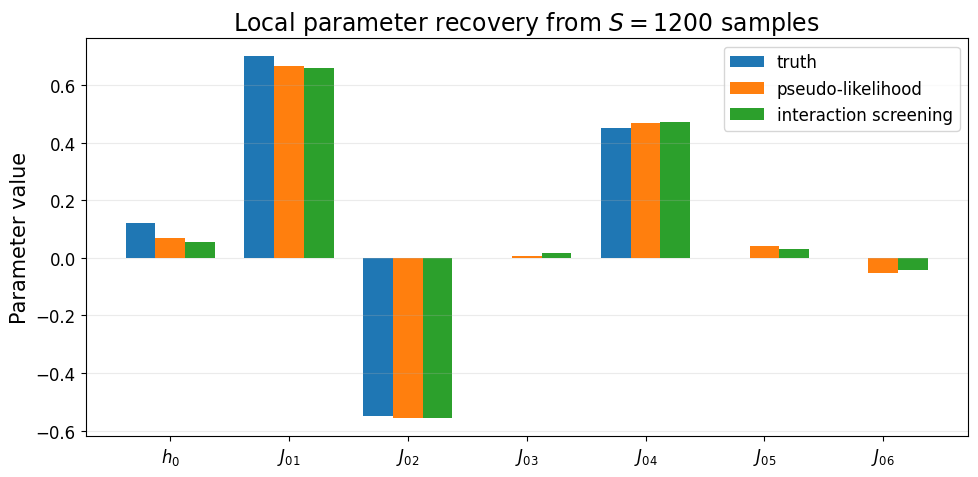

In [3]:
S=1200; data=draw(S); th_pl=fit(data,'pl'); th_is=fit(data,'is')
labels=['$h_0$']+[f'$J_{{0{b}}}$' for b in others]; x=np.arange(len(labels)); width=.25
fig,ax=plt.subplots(figsize=(10,5)); ax.bar(x-width,true_theta,width,label='truth'); ax.bar(x,th_pl,width,label='pseudo-likelihood'); ax.bar(x+width,th_is,width,label='interaction screening')
ax.set_xticks(x,labels); ax.set_ylabel('Parameter value'); ax.set_title(f'Local parameter recovery from $S={S}$ samples'); ax.legend(); ax.grid(axis='y',alpha=.25)
fig.tight_layout(); save_figure(fig,'ch10_02_local_parameter_recovery'); plt.show()

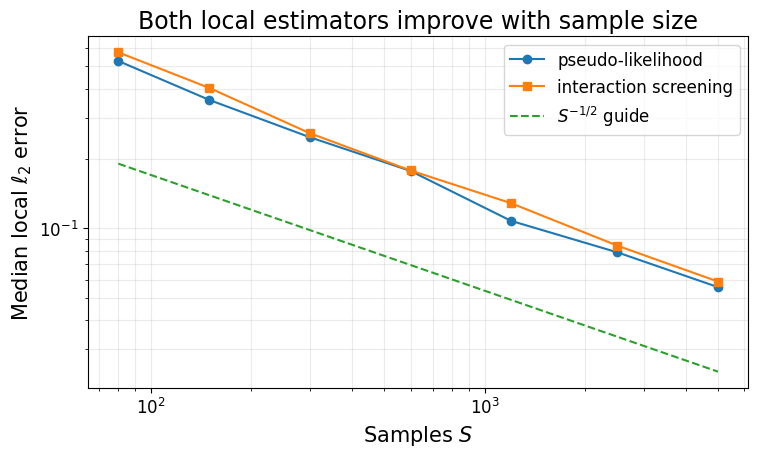

In [4]:
sizes=np.array([80,150,300,600,1200,2500,5000]); reps=24; err_pl=[]; err_is=[]
for S in sizes:
    e1=[];e2=[]
    for _ in range(reps):
      d=draw(int(S)); e1.append(np.linalg.norm(fit(d,'pl')-true_theta)); e2.append(np.linalg.norm(fit(d,'is')-true_theta))
    err_pl.append(np.median(e1)); err_is.append(np.median(e2))
fig,ax=plt.subplots(figsize=(7.8,4.8)); ax.loglog(sizes,err_pl,marker='o',label='pseudo-likelihood'); ax.loglog(sizes,err_is,marker='s',label='interaction screening'); ax.loglog(sizes,1.7/np.sqrt(sizes),linestyle='--',label='$S^{-1/2}$ guide')
ax.set_xlabel('Samples $S$'); ax.set_ylabel(r'Median local $\ell_2$ error'); ax.set_title('Both local estimators improve with sample size'); ax.grid(True,which='both',alpha=.25); ax.legend(); fig.tight_layout(); save_figure(fig,'ch10_02_error_scaling'); plt.show()

## Exercises

1. Add an $\ell_1$ penalty and investigate support recovery as the regularization strength changes.
2. Repeat the experiment after doubling all couplings. Explain why low-temperature learning becomes statistically harder.
3. Fit every node neighborhood independently. Propose and test a rule for reconciling the two estimates of each symmetric coupling $J_{ab}=J_{ba}$.